In [58]:
import pandas as pd
import numpy as np

In [59]:
df = pd.read_csv("smartcart_customers.csv")

In [60]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [61]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [62]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [63]:
df.dtypes

ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
Complain                 int64
Response                 int64
dtype: object

In [64]:
df.duplicated().sum()

np.int64(0)

In [65]:
from datetime import datetime

current_year = datetime.now().year
df["Age"] = current_year - df["Year_Birth"]

In [66]:
df["TotalSpent"] = (df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"]+df["MntGoldProds"])

In [67]:
df["TotalPurchases"] = (
    df["NumDealsPurchases"] +
    df["NumWebPurchases"] + 
    df["NumCatalogPurchases"] + 
    df["NumStorePurchases"]
)

In [68]:
df["FamilySize"] = (
    df["Kidhome"] +
    df["Teenhome"] +
    2
)

In [69]:
cols = ["ID", "Year_Birth", "Marital_Status", "Kidhome", "Teenhome", "Dt_Customer"]
spending_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]

cols_to_drop = cols + spending_cols

df= df.drop(columns=cols_to_drop)

In [70]:
df.corr(numeric_only = True)

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,TotalSpent,TotalPurchases,FamilySize
Income,1.000000,-0.004061,-0.082315,0.380554,0.586826,0.526600,-0.549785,-0.027187,0.132867,0.160899,0.664775,0.563450,-0.290858
Recency,-0.004061,1.000000,-0.001098,-0.010726,0.025110,0.000799,-0.021445,0.013231,-0.198437,0.019871,0.020433,0.005740,0.018053
NumDealsPurchases,-0.082315,-0.001098,1.000000,0.234185,-0.008617,0.068879,0.347633,0.000420,0.002238,0.060846,-0.065112,0.362334,0.439684
NumWebPurchases,0.380554,-0.010726,0.234185,1.000000,0.378376,0.502713,-0.055846,-0.016310,0.148730,0.145040,0.519837,0.777831,-0.146361
NumCatalogPurchases,0.586826,0.025110,-0.008617,0.378376,1.000000,0.518738,-0.520364,-0.020453,0.220810,0.121275,0.778577,0.735198,-0.439904
NumStorePurchases,0.526600,0.000799,0.068879,0.502713,0.518738,1.000000,-0.428473,-0.016524,0.039363,0.128272,0.674669,0.820259,-0.321125
NumWebVisitsMonth,-0.549785,-0.021445,0.347633,-0.055846,-0.520364,-0.428473,1.000000,0.019769,-0.003987,-0.121139,-0.500218,-0.312288,0.418419
Complain,-0.027187,0.013231,0.000420,-0.016310,-0.020453,-0.016524,0.019769,1.000000,-0.001707,0.030128,-0.037058,-0.020583,0.031066
Response,0.132867,-0.198437,0.002238,0.148730,0.220810,0.039363,-0.003987,-0.001707,1.000000,-0.021325,0.265298,0.155138,-0.169163
Age,0.160899,0.019871,0.060846,0.145040,0.121275,0.128272,-0.121139,0.030128,-0.021325,1.000000,0.111306,0.168304,0.090199


In [71]:
df.shape

(2240, 14)

In [72]:
from sklearn.preprocessing import StandardScaler

In [73]:
scaler = StandardScaler()

In [74]:
df = pd.get_dummies(df)
X = df.astype(int)

In [75]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,TotalSpent,TotalPurchases,FamilySize,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD
0,58138,58,3,8,10,4,7,0,1,69,1617,25,2,0,0,1,0,0
1,46344,38,2,1,1,2,5,0,0,72,27,6,4,0,0,1,0,0
2,71613,26,1,8,2,10,4,0,0,61,776,21,2,0,0,1,0,0
3,26646,26,2,2,0,4,6,0,0,42,53,8,3,0,0,1,0,0
4,58293,94,5,5,3,6,5,0,0,45,422,19,3,0,0,0,0,1


In [76]:
X_scaled = scaler.fit_transform(X)

In [77]:
from sklearn.cluster import KMeans

In [79]:
wcss = []

for k in range(1,11):
    kmeans = KMeans(n_clusters = k)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

Text(0.5, 1.0, 'Elbow method')

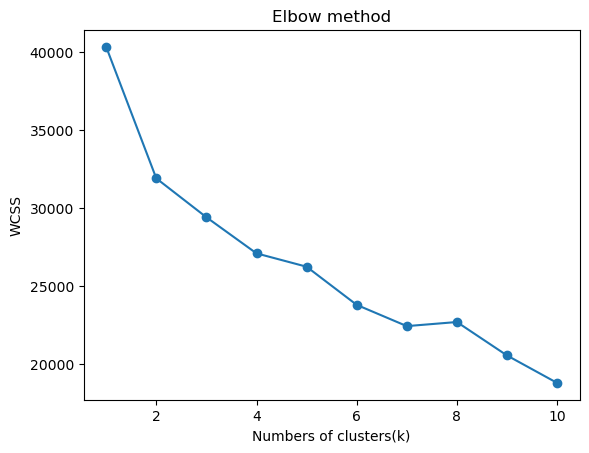

In [80]:
import matplotlib.pyplot as plt

plt.plot(range(1,11) , wcss, marker = 'o')
plt.xlabel("Numbers of clusters(k)")
plt.ylabel("WCSS")
plt.title("Elbow method")


In [81]:
from sklearn.metrics import silhouette_score
for k in range(2,11):
    kmeans = KMeans(n_clusters = k, random_state = 42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled,labels)
    print(f" k = {k} , score = {score}")

 k = 2 , score = 0.2109962177945331
 k = 3 , score = 0.20321582174311298
 k = 4 , score = 0.17603592000451718
 k = 5 , score = 0.19805571485558182
 k = 6 , score = 0.17772576937575094
 k = 7 , score = 0.18246107931794694
 k = 8 , score = 0.21188716815723743
 k = 9 , score = 0.22401541321679166
 k = 10 , score = 0.21469597708851038


In [82]:
kmeans = KMeans(
    n_clusters = 4, 
    random_state = 42
)
labels = kmeans.fit_predict(X_scaled)

In [83]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X_scaled)


Text(0, 0.5, 'pc2')

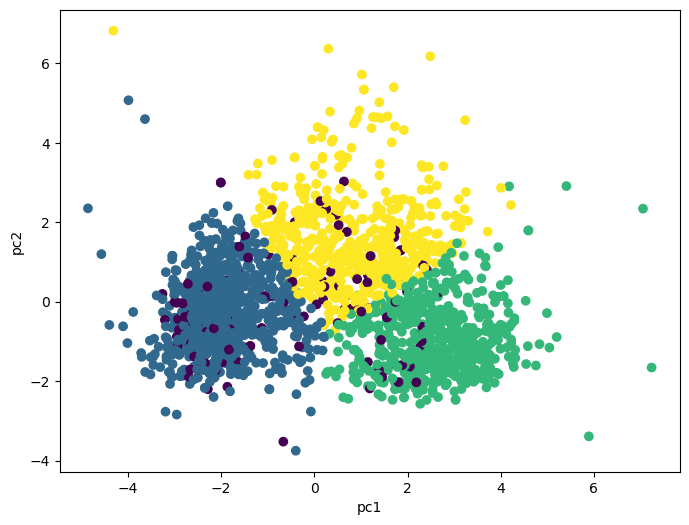

In [84]:
plt.figure(figsize = (8,6))
plt.scatter(X_pca[:,0],X_pca[:,1],c = labels)
plt.xlabel("pc1")
plt.ylabel("pc2")

In [85]:
df["Cluster"] = labels
df.groupby("Cluster").mean(numeric_only = True)

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,TotalSpent,TotalPurchases,FamilySize,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD
Cluster,,,,,,,,,,,,,,,,,,
0,43204.631429,48.822857,2.211429,3.297143,1.577143,4.805714,5.731429,0.017143,0.062857,53.108571,359.668571,11.891429,2.982857,1.000000,0.000000,0.000000,0.000000,0.000000
1,35627.963626,49.153094,1.915309,2.086862,0.565689,3.198697,6.390879,0.009772,0.086862,55.095548,98.749186,7.766558,3.224756,0.000000,0.057546,0.560261,0.180239,0.201954
2,76196.491667,49.446667,1.261667,5.026667,5.983333,8.410000,2.776667,0.006667,0.283333,58.360000,1343.698333,20.681667,2.230000,0.038333,0.000000,0.581667,0.155000,0.225000
3,56840.082721,48.755515,4.227941,6.681985,2.897059,7.604779,6.165441,0.009191,0.134191,60.775735,729.556985,21.411765,3.270221,0.009191,0.001838,0.481618,0.204044,0.303309


In [86]:
df["Cluster"].value_counts()

Cluster
1    921
2    600
3    544
0    175
Name: count, dtype: int64

In [87]:
cluster_summary = df.groupby("Cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
Cluster                                                                
0        43204.631429  48.822857           2.211429         3.297143   
1        35627.963626  49.153094           1.915309         2.086862   
2        76196.491667  49.446667           1.261667         5.026667   
3        56840.082721  48.755515           4.227941         6.681985   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
Cluster                                                                        
0                   1.577143           4.805714           5.731429  0.017143   
1                   0.565689           3.198697           6.390879  0.009772   
2                   5.983333           8.410000           2.776667  0.006667   
3                   2.897059           7.604779           6.165441  0.009191   

         Response        Age   TotalSpent  TotalPurchases  FamilySize  \
Cluster      